In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = Path("../data/processed/corpus_500k.parquet")

corpus = pd.read_parquet(DATA_PATH)

corpus.head()

,doc_id,job_link,job_title,company,job_location,search_city,search_country,search_position,job_level,job_type,job_summary,job_skills,search_text
0,JOB_0000001,https://uk.linkedin.com/jobs/view/customer-ser...,Customer Service Representative,Elite Recruitment Solutions Maidenhead,"Reading, England, United Kingdom",Slough,United Kingdom,Customer Service Representative,Mid senior,Onsite,We are proud to be supporting a manufacturer a...,"Customer service, Communication skills, Keyboa...",Title: Customer Service Representative. Summar...
1,JOB_0000002,https://www.linkedin.com/jobs/view/commercial-...,Commercial Counsel,LiveRamp,"Little Rock, AR",Little Rock,United States,Lawyer,Mid senior,Onsite,LiveRamp is the data collaboration platform of...,"Commercial Contracting Experience, Legal Guida...",Title: Commercial Counsel. Summary: LiveRamp i...
2,JOB_0000003,https://www.linkedin.com/jobs/view/per-diem-di...,Per Diem Dialysis Registered Nurse - RN at Fre...,Health eCareers,"Mount Vernon, WA",Anacortes,United States,Dialysis Technician,Mid senior,Onsite,PURPOSE AND SCOPE:**The professional registere...,"Hemodialysis, Nursing, Pharmacology, Patient A...",Title: Per Diem Dialysis Registered Nurse - RN...
3,JOB_0000004,https://www.linkedin.com/jobs/view/manager-fle...,"Manager, Fleet Maintenance","MTM, Inc.","Warren, MI",Macomb,United States,Safety Manager,Mid senior,Onsite,"What Will Your Job Look Like? The Manager, Fle...","Fleet Maintenance, Automotive Mechanical, Mech...","Title: Manager, Fleet Maintenance. Summary: Wh..."
4,JOB_0000005,https://www.linkedin.com/jobs/view/workforce-d...,Workforce Development Adjunct,Rose State College,"Midwest City, OK",Midwest City,United States,Instructor,Mid senior,Onsite,WORKFORCE DEVELOPMENT ANNOUNCES OPENINGS FOR A...,"Python, Software development, Linux, System ad...",Title: Workforce Development Adjunct. Summary:...


In [2]:
print(f"Documents: {len(corpus):,}")

print("\nColumns:")
print(corpus.columns.tolist())

corpus.info()

Documents: 500,000

Columns:
['doc_id', 'job_link', 'job_title', 'company', 'job_location', 'search_city', 'search_country', 'search_position', 'job_level', 'job_type', 'job_summary', 'job_skills', 'search_text']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   doc_id           500000 non-null  object
 1   job_link         500000 non-null  string
 2   job_title        500000 non-null  object
 3   company          500000 non-null  object
 4   job_location     500000 non-null  object
 5   search_city      500000 non-null  object
 6   search_country   500000 non-null  object
 7   search_position  500000 non-null  object
 8   job_level        500000 non-null  object
 9   job_type         500000 non-null  object
 10  job_summary      500000 non-null  object
 11  job_skills       500000 non-null  object
 12  search_text      500000 non

In [3]:
missing = corpus.isna().sum()
missing

doc_id             0
job_link           0
job_title          0
company            0
job_location       0
search_city        0
search_country     0
search_position    0
job_level          0
job_type           0
job_summary        0
job_skills         0
search_text        0
dtype: int64

In [4]:
country_counts = (
    corpus["search_country"]
    .value_counts()
    .head(20)
)

country_counts

search_country
United States     425364
United Kingdom     42347
Canada             21016
Australia          11273
Name: count, dtype: int64

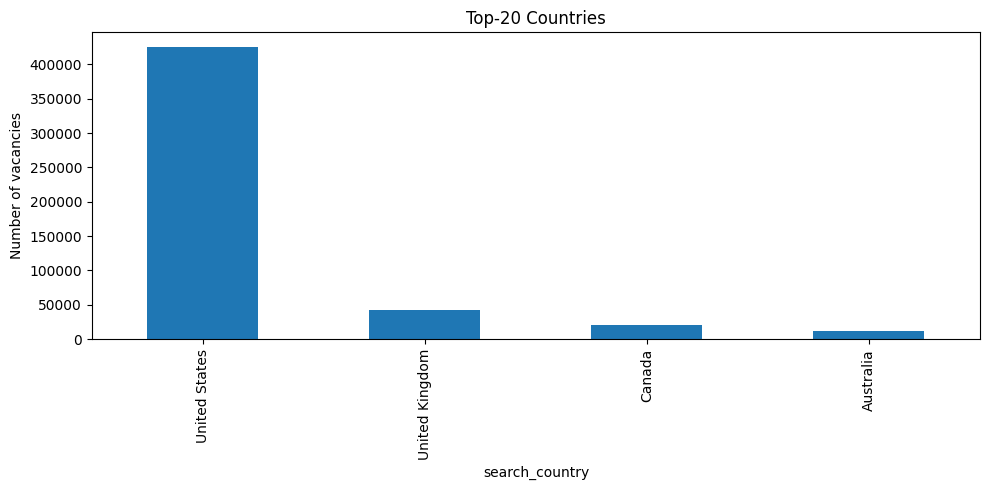

In [5]:
country_counts.plot(kind="bar")

plt.title("Top-20 Countries")
plt.ylabel("Number of vacancies")
plt.tight_layout()
plt.show()

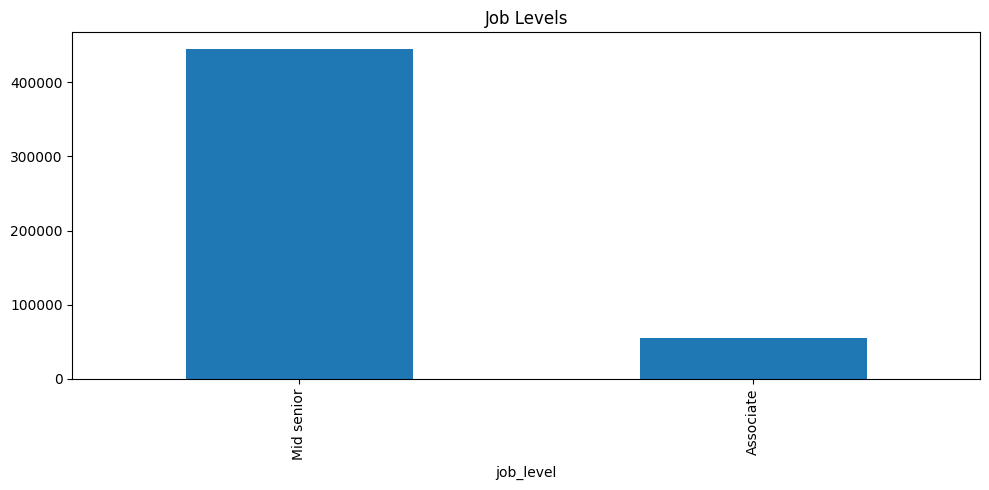

In [6]:
level_counts = corpus["job_level"].value_counts()
level_counts

level_counts.plot(kind="bar")
plt.title("Job Levels")
plt.tight_layout()
plt.show()

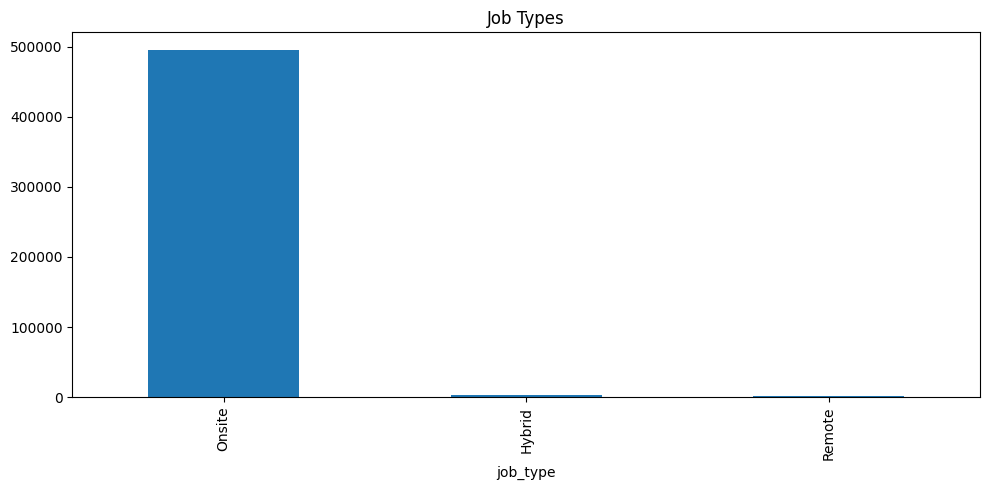

In [11]:
type_counts = corpus["job_type"].value_counts()
type_counts

type_counts.plot(kind="bar")
plt.title("Job Types")
plt.tight_layout()
plt.show()


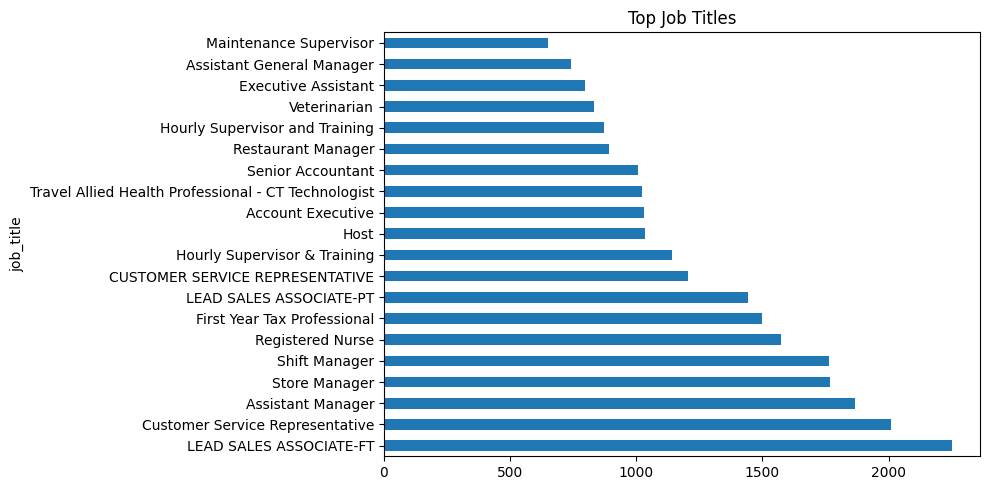

In [12]:
titles = (
    corpus["job_title"]
    .value_counts()
    .head(20)
)

titles

titles.plot(kind="barh")
plt.title("Top Job Titles")
plt.tight_layout()
plt.show()

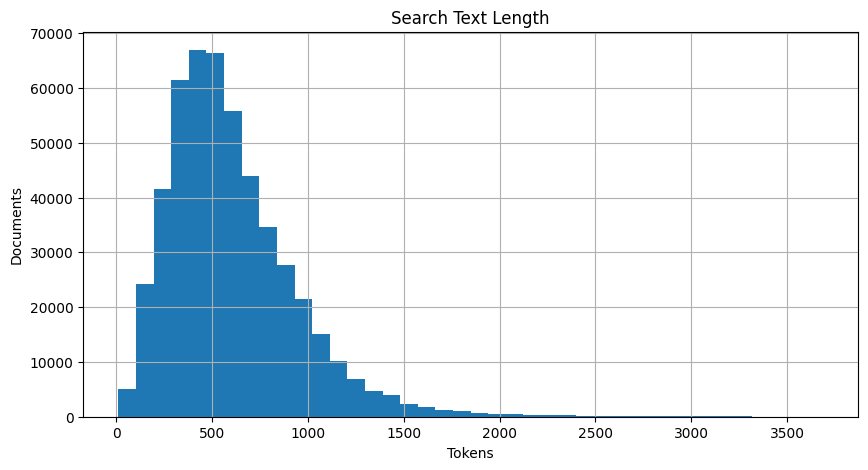

In [13]:
corpus["tokens"] = corpus["search_text"].str.split().str.len()
corpus["tokens"].describe()

corpus["tokens"].hist(bins=40)
plt.title("Search Text Length")
plt.xlabel("Tokens")
plt.ylabel("Documents")
plt.show()

In [ ]:
print("Documents:", len(corpus))
print("Countries:", corpus["search_country"].nunique())
print("Companies:", corpus["company"].nunique())
print("Job titles:", corpus["job_title"].nunique())

corpus["company"].value_counts().head(20)
corpus["search_country"].value_counts(normalize=True) * 100